# Module 4, Class 1: Linear Regression

**Student:** Firdavs Boliev  
**Dataset:** Superstore Sales

This notebook keeps the workflow simple: load data, train linear regression models, compare metrics, and explain the result in plain language.


## 0. Setup

In [1]:
# Import the libraries needed for data analysis, plotting, and regression models.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


Setup complete.


## 1. Load Data

In [2]:
# Load the Superstore dataset from a working raw CSV link and preview the first rows.
# Superstore dataset from a working raw CSV link
url = "https://gist.githubusercontent.com/nnbphuong/38db511db14542f3ba9ef16e69d3814c/raw/3a77ff9d97c504d3ec3210b12fde7242b8c6ab63/Superstore.csv"

try:
    df = pd.read_csv(url, encoding='windows-1252')
except Exception:
    df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()


Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Keep a simple upload fallback as comments in case the online CSV is not available.
# Fallback: upload if URL fails
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0], encoding='windows-1252')


In [4]:
# Inspect the numeric columns that will be used in the regression examples.
# Quick inspection of numeric columns
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Simple Linear Regression: Sales ~ Discount

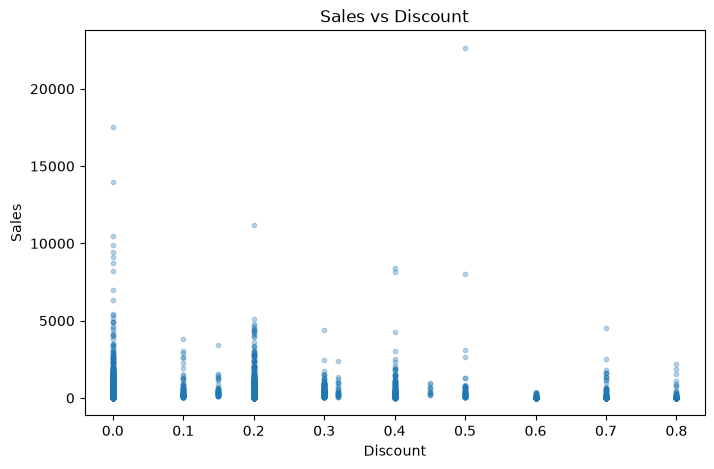

In [5]:
# Plot Sales against Discount to see whether a straight-line model may help.
# Scatter plot to see the relationship
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Sales'], alpha=0.3, s=10)
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.title('Sales vs Discount')
plt.show()


In [6]:
# Train a simple linear regression model using only Discount to predict Sales.
# Prepare data
X_simple = df[['Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train simple linear regression
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)
y_pred_simple = lr_simple.predict(X_test)

print(f"Coefficient (slope): {lr_simple.coef_[0]:.4f}")
print(f"Intercept: {lr_simple.intercept_:.4f}")
print(f"\nInterpretation: For each 1-unit increase in Discount,")
print(f"Sales changes by {lr_simple.coef_[0]:.2f} on average.")


Coefficient (slope): -126.7518
Intercept: 245.5065

Interpretation: For each 1-unit increase in Discount,
Sales changes by -126.75 on average.


## 3. Multiple Linear Regression

In [7]:
# Train a multiple linear regression model using Discount, Quantity, and Profit.
# Use multiple features
X_multi = df[['Discount', 'Quantity', 'Profit']]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)
y_pred_multi = lr_multi.predict(X_test_m)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': lr_multi.coef_
})
print("Coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_multi.intercept_:.4f}")


Coefficients:
 Feature  Coefficient
Discount   249.571780
Quantity    41.550264
  Profit     1.561674

Intercept: -18.0971


## 4. Evaluation Metrics

In [8]:
# Define one small helper function to evaluate regression models with common metrics.
def evaluate_regression(y_true, y_pred, model_name="Model"):
    """Compute and print regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}")
    print()
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

metrics_simple = evaluate_regression(y_test, y_pred_simple, "Simple LR (Discount only)")
metrics_multi = evaluate_regression(y_test_m, y_pred_multi, "Multiple LR (Discount + Quantity + Profit)")


--- Simple LR (Discount only) ---
MSE:  592714.18
RMSE: 769.88
MAE:  286.23
R2:   -0.0034

--- Multiple LR (Discount + Quantity + Profit) ---
MSE:  680377.46
RMSE: 824.85
MAE:  245.08
R2:   -0.1518



## 5. Coefficient Interpretation

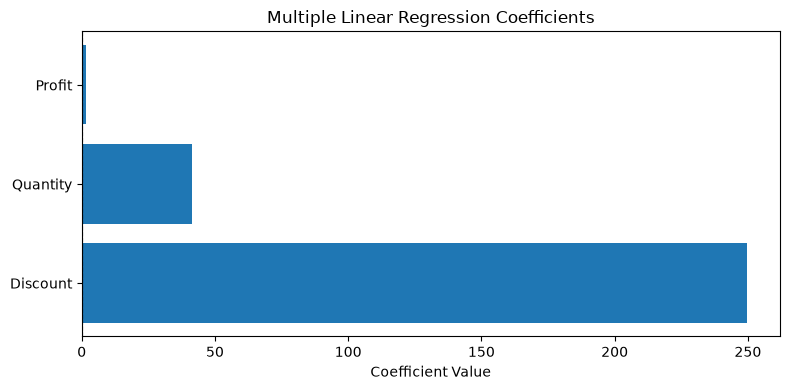

Each coefficient tells you: holding other features constant,
a 1-unit increase in this feature changes Sales by this amount.


In [9]:
# Plot the multiple regression coefficients so their direction is easy to compare.
# Visualize coefficients
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Multiple Linear Regression Coefficients')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Each coefficient tells you: holding other features constant,")
print("a 1-unit increase in this feature changes Sales by this amount.")


## 6. Residual Plot

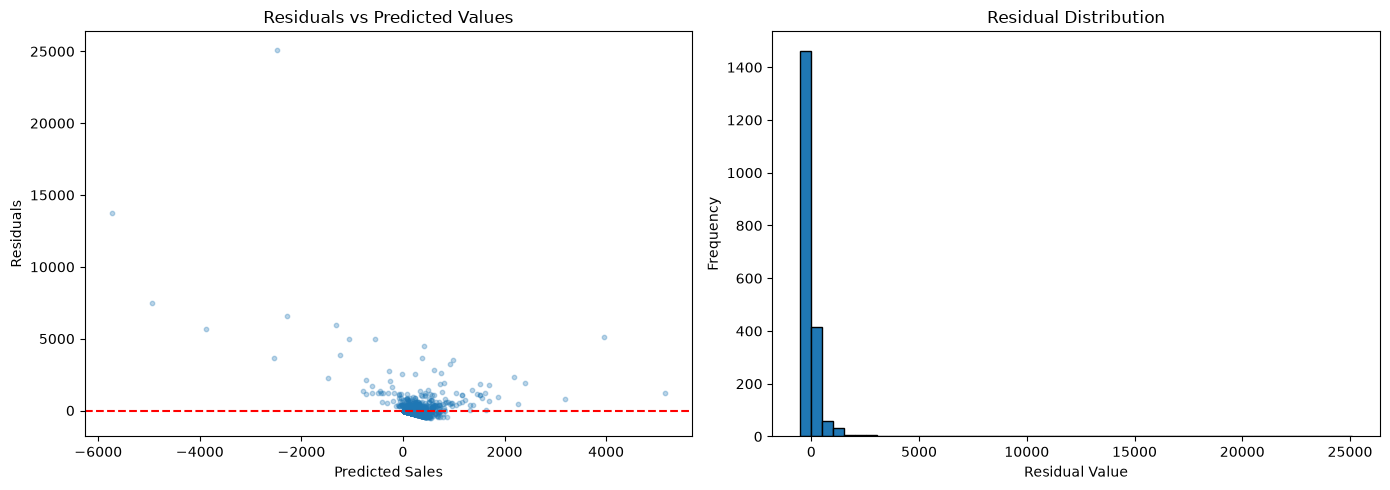

Ideal residual plot: randomly scattered around 0, no pattern.
A pattern suggests the model is missing something (non-linearity, interactions, etc.).


In [10]:
# Plot residuals to check whether the model is missing a clear pattern.
residuals = y_test_m - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_multi, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print("Ideal residual plot: randomly scattered around 0, no pattern.")
print("A pattern suggests the model is missing something (non-linearity, interactions, etc.).")


## 7. Polynomial Features

Linear regression assumes a linear relationship. Polynomial features can capture non-linear patterns.

**Your tasks:**
1. Create polynomial features of degree 2 and degree 3
2. Train linear regression on each
3. Compare all models (linear, degree 2, degree 3) using the evaluation metrics

In [11]:
# Train polynomial regression models with degree 2 and degree 3 features.
# Create degree 2 polynomial features from the same multiple-regression inputs.
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_m)
X_test_poly2 = poly2.transform(X_test_m)

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train_m)
y_pred_poly2 = lr_poly2.predict(X_test_poly2)

metrics_poly2 = evaluate_regression(
    y_test_m,
    y_pred_poly2,
    "Polynomial LR (degree 2)"
)

# Create degree 3 polynomial features and train another linear regression model.
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_m)
X_test_poly3 = poly3.transform(X_test_m)

lr_poly3 = LinearRegression()
lr_poly3.fit(X_train_poly3, y_train_m)
y_pred_poly3 = lr_poly3.predict(X_test_poly3)

metrics_poly3 = evaluate_regression(
    y_test_m,
    y_pred_poly3,
    "Polynomial LR (degree 3)"
)


--- Polynomial LR (degree 2) ---
MSE:  489445.07
RMSE: 699.60
MAE:  204.26
R2:   0.1714

--- Polynomial LR (degree 3) ---
MSE:  466150.52
RMSE: 682.75
MAE:  257.04
R2:   0.2108



In [12]:
# Put all model metrics into one comparison table.
# Combine all metric dictionaries into one DataFrame.
comparison_df = pd.DataFrame([
    metrics_simple,
    metrics_multi,
    metrics_poly2,
    metrics_poly3,
])

# Round values so the table is easier to read.
comparison_df = comparison_df.round(4)
comparison_df


,model,MSE,RMSE,MAE,R2
0,Simple LR (Discount only),592714.1809,769.8793,286.2348,-0.0034
1,Multiple LR (Discount + Quantity + Profit),680377.4564,824.8500,245.0756,-0.1518
2,Polynomial LR (degree 2),489445.0716,699.6035,204.2608,0.1714
3,Polynomial LR (degree 3),466150.5163,682.7522,257.0373,0.2108


### Polynomial Model Interpretation

The degree 2 and degree 3 models add curved relationships between the features. In this run, the degree 3 model gives the best R-squared, so it explains more Sales variation than the simple straight-line models. The model is still not perfect, which means Sales depends on more business factors than Discount, Quantity, and Profit alone.


## 8. Gradient Descent Visualization (Demo)

This cell shows how gradient descent minimizes the loss function step by step. You do not need to modify this -- just run it and observe.

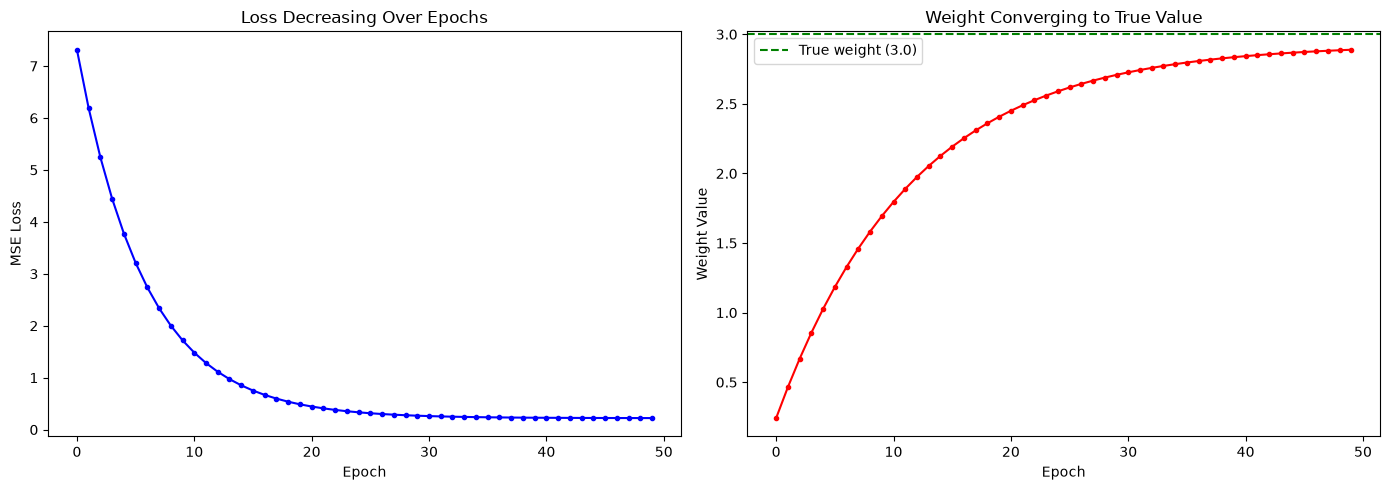

Final weight: 2.8889 (true: 3.0)
Final loss: 0.2224


In [13]:
# Run a small gradient descent demo to show how a weight improves over time.
# Simple gradient descent demo on a 1D problem
# Minimize MSE for: y = w * x (single weight, no bias)

np.random.seed(42)
x_gd = np.random.randn(100)
y_gd = 3.0 * x_gd + np.random.randn(100) * 0.5  # true weight = 3.0

# Gradient descent
w = 0.0  # initial weight
lr = 0.05  # learning rate
n_epochs = 50
history = []

for epoch in range(n_epochs):
    # Prediction
    y_hat = w * x_gd
    # Loss (MSE)
    loss = np.mean((y_gd - y_hat) ** 2)
    # Gradient: d(MSE)/dw = -2 * mean(x * (y - y_hat))
    grad = -2 * np.mean(x_gd * (y_gd - y_hat))
    # Update
    w = w - lr * grad
    history.append({'epoch': epoch, 'weight': w, 'loss': loss})

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss over epochs
axes[0].plot(history_df['epoch'], history_df['loss'], 'b-o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Decreasing Over Epochs')

# Weight convergence
axes[1].plot(history_df['epoch'], history_df['weight'], 'r-o', markersize=3)
axes[1].axhline(y=3.0, color='green', linestyle='--', label='True weight (3.0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weight Value')
axes[1].set_title('Weight Converging to True Value')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final weight: {w:.4f} (true: 3.0)")
print(f"Final loss: {history_df['loss'].iloc[-1]:.4f}")


---
## Summary

| Concept | Details |
|---------|---------|
| Simple LR | One feature predicting target |
| Multiple LR | Multiple features |
| MSE / RMSE | Penalize large errors more |
| MAE | Average absolute error (robust to outliers) |
| R-squared | Proportion of variance explained (0 to 1) |
| Residuals | Predicted - Actual; should be random around 0 |
| Polynomial | Captures non-linear relationships |
| Gradient Descent | Iteratively adjusts weights to minimize loss |